# ADCNN evaluation — catalog-based

Pure analysis of the **pre-generated detection catalogs** (`Evaluation/catalogs/`, from
`make_eval_catalogs`: deployed v7 + neg5 RF, `gate_pmax=0.10`, RF cut at `DEFAULT_THR`). No NN
inference, no training, no test-set threshold tuning. For each σ set it matches the measured
catalog to truth (any-pixel-overlap, fixed `tol_px`, all-trails denominator) and reports object-
level NN metrics + FP, the **NN vs LSST-stack vs combined** comparison, completeness, and (5σ)
parameter recovery. The LSST-stack baseline (recall + FP) is read straight from the stack
footprints (`real_labels`) — a fast max-reduce, no inference. (Pixelwise confusion + the RF score
sweep are intentionally omitted.)

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd, h5py, matplotlib.pyplot as plt
REPO = Path('.').resolve(); sys.path.insert(0, str(REPO))
import ADCNN.evaluation.detection as evals
from ADCNN.evaluation.catalog_match import evaluate_catalog, match_pairs
from ADCNN.inference.rf_postproc import DEFAULT_THR

CATALOGS = REPO/'Evaluation/catalogs'; DATA = REPO/'DATA_DIFFIM'; TOL_PX = 20.0
SETS = ['test_5sigma','test_4sigma','test_3sigma']
print(f'RF cut = {DEFAULT_THR} | match tol = {TOL_PX}px | catalogs = {CATALOGS}')

_STACK_FP = {}
def stack_fp_count(name):
    """LSST-stack false positives = total stack/DIA components = sum of per-panel max of the
    (labeled) real_labels footprint mask. Fast read + max-reduce — no inference."""
    if name not in _STACK_FP:
        with h5py.File(DATA/name/'test.h5','r') as f:
            rl = f['real_labels']
            _STACK_FP[name] = int(sum(int(rl[i].max()) for i in range(rl.shape[0])))
    return _STACK_FP[name]

def evaluate_set(name):
    cat = pd.read_csv(CATALOGS/f'{name}_detections.csv')
    truth = pd.read_csv(DATA/name/'test.csv')
    counts, t = evaluate_catalog(cat, truth, tol_px=TOL_PX)
    t['stack_detection'] = t['stack_detection'].astype(bool)
    return counts, t, match_pairs(cat, truth, tol_px=TOL_PX), cat

def show_confusion(counts, title):
    evals.print_confusion_matrix({'TN': pd.NA, 'FP': counts['FP'], 'FN': counts['FN'], 'TP': counts['TP']}, title=title)

def compare_methods(name, counts, t):
    nn=t['nn_detected'].astype(bool); st=t['stack_detection']; comb=nn|st; n=len(t); npan=t['image_id'].nunique()
    sfp=stack_fp_count(name)
    print(f'\n[{name}] NN vs LSST-stack vs combined (n={n} truth trails, {npan} panels):')
    print(f'  LSST stack : recall={st.mean():.3f} ({int(st.sum())})   FP={sfp}  ({sfp/npan:.1f}/panel)')
    print(f'  v7+RF NN   : recall={nn.mean():.3f} ({int(nn.sum())})   FP={counts["FP"]}  ({counts["fp_per_panel"]:.1f}/panel)')
    print(f'  combined   : recall={comb.mean():.3f} ({int(comb.sum())})')
    print(f'  NN recovers {int((nn & ~st).sum())} stack-missed trails (pure 2nd-stage gain)')
    return dict(set=name.replace('test_',''), NN_recall=round(nn.mean(),3), stack_recall=round(st.mean(),3),
                combined_recall=round(comb.mean(),3), NN_FP=counts['FP'], NN_FP_pp=round(counts['fp_per_panel'],1),
                stack_FP=sfp, stack_FP_pp=round(sfp/npan,1))

RF cut = 0.5 | match tol = 20.0px | catalogs = /sdf/data/rubin/user/mrakovci/Projects/Asteroid_detection_CNN/Evaluation/catalogs


## test_5sigma + NN (hero)

test_5sigma + NN — object-level (catalog trail-overlap)
F1 Score: 0.2736, F2 Score: 0.4367
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>                3575
Actual Positive                 275                 725




[test_5sigma] NN vs LSST-stack vs combined (n=1000 truth trails, 50 panels):
  LSST stack : recall=0.475 (475)   FP=6405  (128.1/panel)
  v7+RF NN   : recall=0.725 (725)   FP=3575  (71.5/panel)
  combined   : recall=0.739 (739)
  NN recovers 264 stack-missed trails (pure 2nd-stage gain)


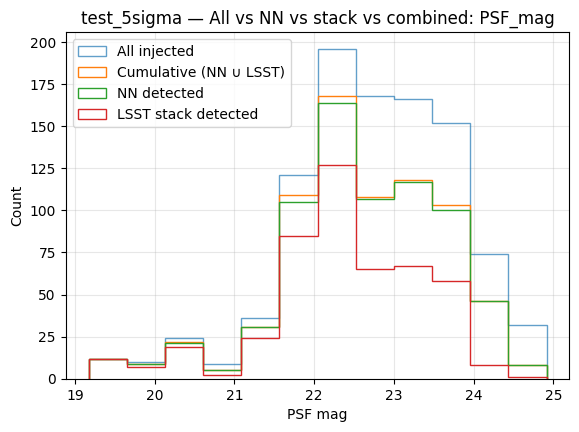

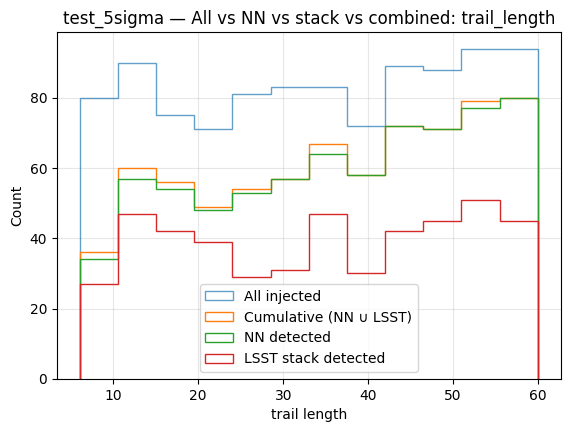

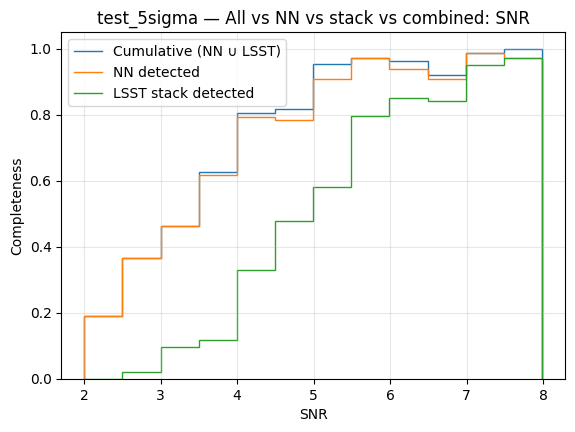

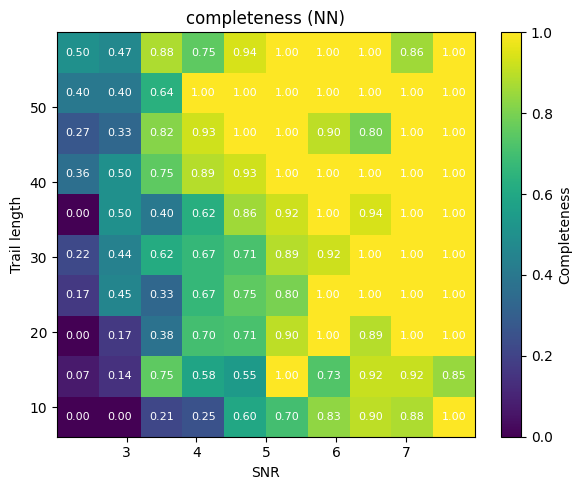

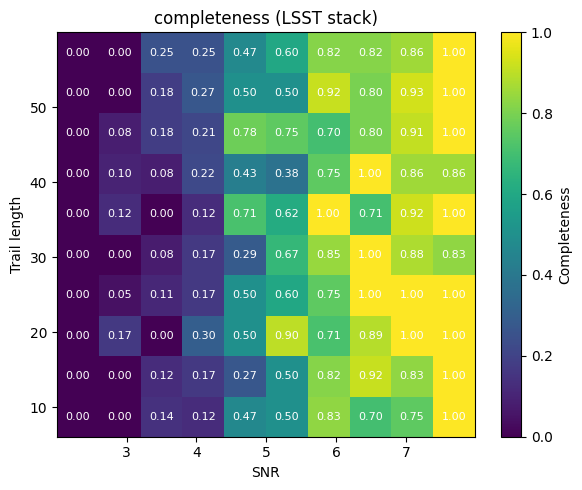

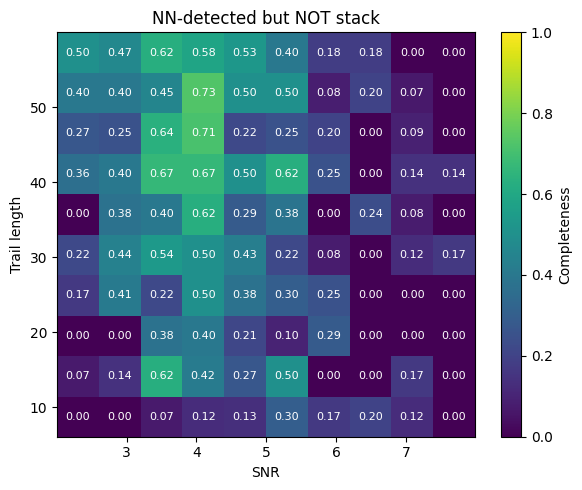

In [2]:
counts, t, pairs, cat = evaluate_set('test_5sigma')
show_confusion(counts, 'test_5sigma + NN — object-level (catalog trail-overlap)')
row = compare_methods('test_5sigma', counts, t)
for field, kw in [('PSF_mag', {}), ('trail_length', {}), ('SNR', dict(xlim=[0,10], density=True))]:
    evals.plot_detect_hist(t, field, bins=12, title='test_5sigma — All vs NN vs stack vs combined: '+field, **kw); plt.show()
evals.plot_completeness_2d(t, snr_bins=10, trail_bins=10, title='completeness (NN)'); plt.show()
evals.plot_completeness_2d(t, snr_bins=10, trail_bins=10, detected=t['stack_detection'].values, title='completeness (LSST stack)'); plt.show()
evals.plot_completeness_2d(t, snr_bins=10, trail_bins=10, detected=(~t['stack_detection'].values & t['nn_detected'].values.astype(bool)), title='NN-detected but NOT stack'); plt.show()

### Parameter recovery — measured vs true geometry (matched trails)

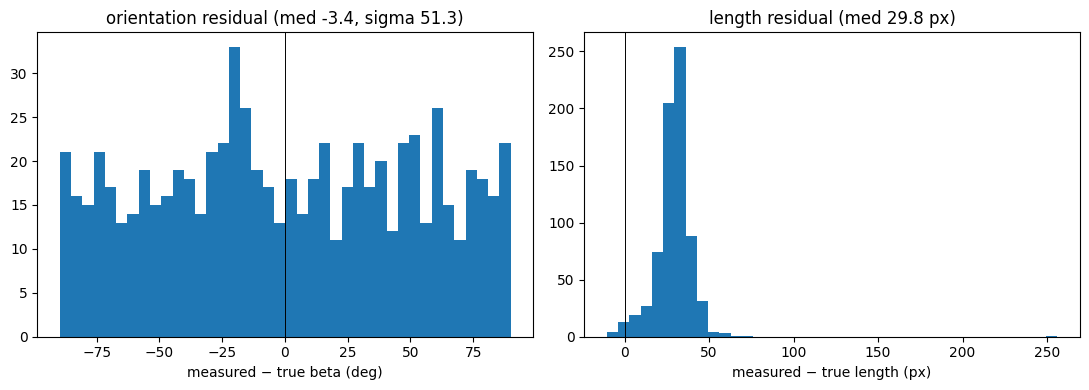

In [3]:
dbeta = ((pairs.meas_beta - pairs.beta + 90) % 180) - 90
dlen = pairs.meas_length - pairs.trail_length
fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].hist(dbeta, bins=40); ax[0].axvline(0,c='k',lw=.7); ax[0].set_xlabel('measured − true beta (deg)'); ax[0].set_title(f'orientation residual (med {dbeta.median():.1f}, sigma {dbeta.std():.1f})')
ax[1].hist(dlen, bins=40); ax[1].axvline(0,c='k',lw=.7); ax[1].set_xlabel('measured − true length (px)'); ax[1].set_title(f'length residual (med {dlen.median():.1f} px)')
plt.tight_layout(); plt.show()

## test_4sigma

test_4sigma + NN — object-level (catalog trail-overlap)
F1 Score: 0.3247, F2 Score: 0.4906
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>                2838
Actual Positive                 256                 744




[test_4sigma] NN vs LSST-stack vs combined (n=1000 truth trails, 50 panels):
  LSST stack : recall=0.682 (682)   FP=15029  (300.6/panel)
  v7+RF NN   : recall=0.744 (744)   FP=2838  (56.8/panel)
  combined   : recall=0.786 (786)
  NN recovers 104 stack-missed trails (pure 2nd-stage gain)


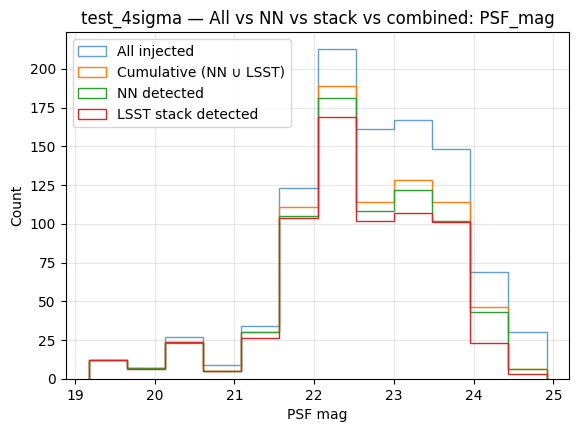

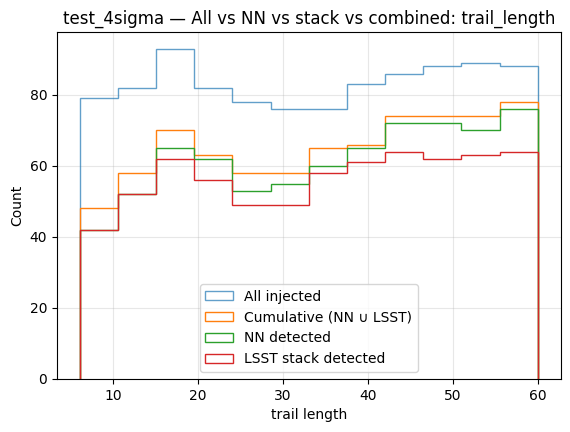

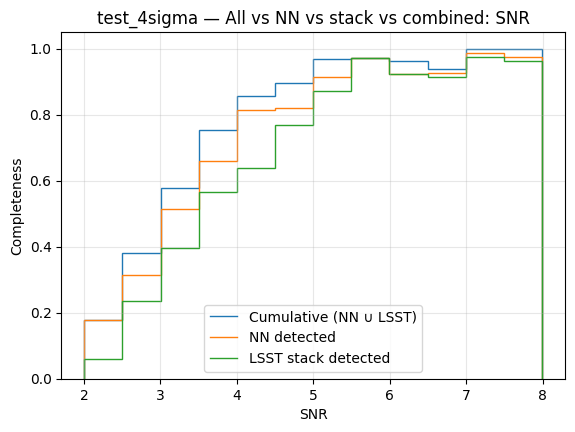

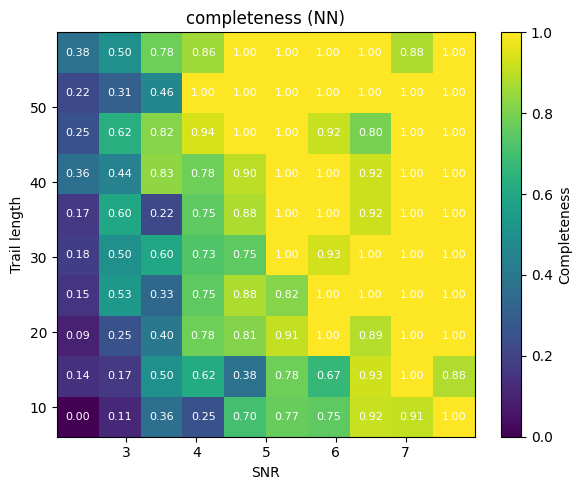

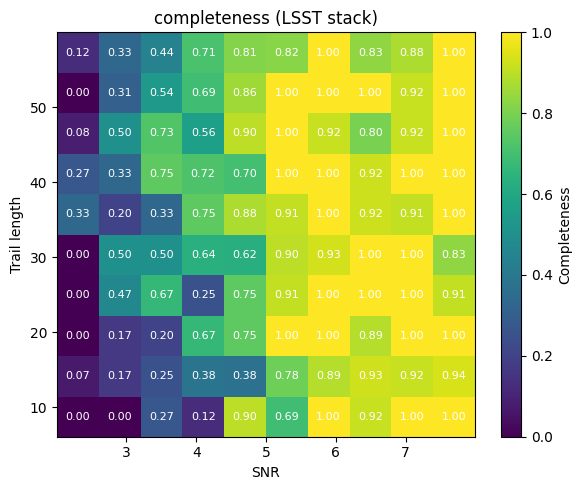

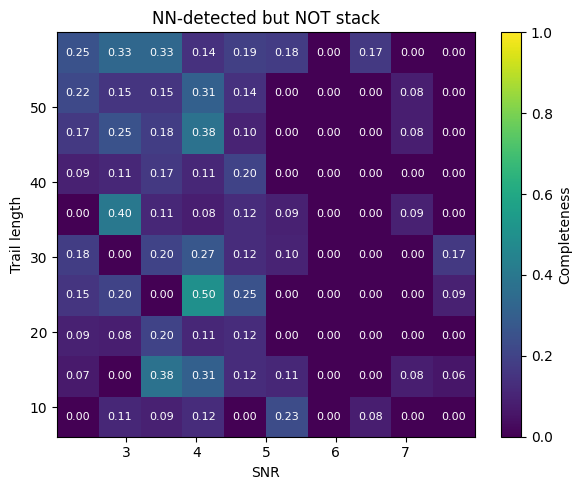

In [4]:
counts, t, pairs, cat = evaluate_set('test_4sigma')
show_confusion(counts, 'test_4sigma + NN — object-level (catalog trail-overlap)')
row = compare_methods('test_4sigma', counts, t)
for field, kw in [('PSF_mag', {}), ('trail_length', {}), ('SNR', dict(xlim=[0,10], density=True))]:
    evals.plot_detect_hist(t, field, bins=12, title='test_4sigma — All vs NN vs stack vs combined: '+field, **kw); plt.show()
evals.plot_completeness_2d(t, snr_bins=10, trail_bins=10, title='completeness (NN)'); plt.show()
evals.plot_completeness_2d(t, snr_bins=10, trail_bins=10, detected=t['stack_detection'].values, title='completeness (LSST stack)'); plt.show()
evals.plot_completeness_2d(t, snr_bins=10, trail_bins=10, detected=(~t['stack_detection'].values & t['nn_detected'].values.astype(bool)), title='NN-detected but NOT stack'); plt.show()

## test_3sigma

test_3sigma + NN — object-level (catalog trail-overlap)
F1 Score: 0.4710, F2 Score: 0.6209
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>                1558
Actual Positive                 212                 788




[test_3sigma] NN vs LSST-stack vs combined (n=1000 truth trails, 50 panels):
  LSST stack : recall=0.879 (879)   FP=142072  (2841.4/panel)
  v7+RF NN   : recall=0.788 (788)   FP=1558  (31.2/panel)
  combined   : recall=0.909 (909)
  NN recovers 30 stack-missed trails (pure 2nd-stage gain)


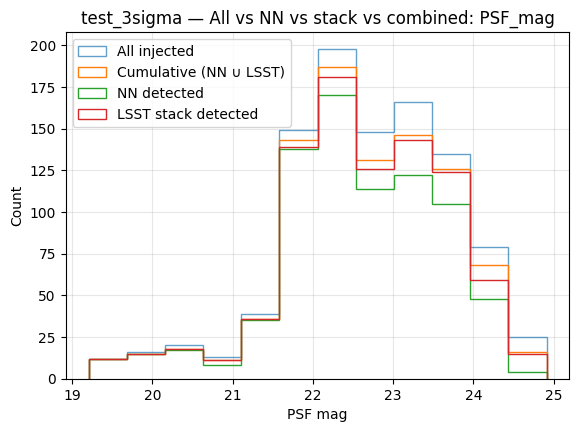

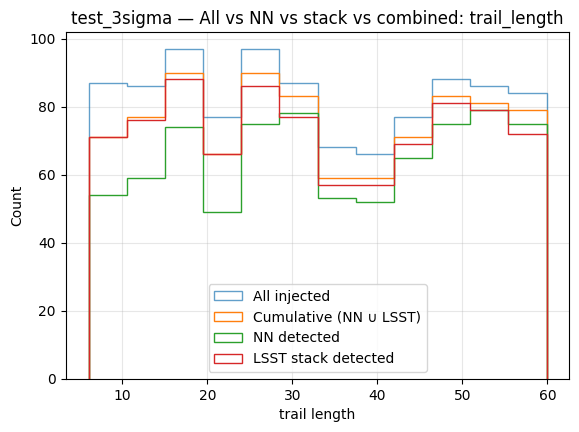

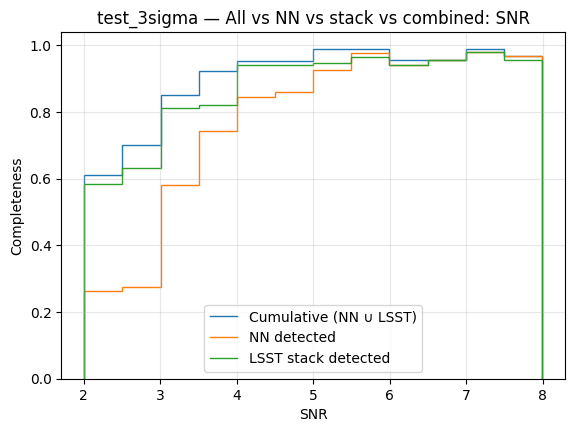

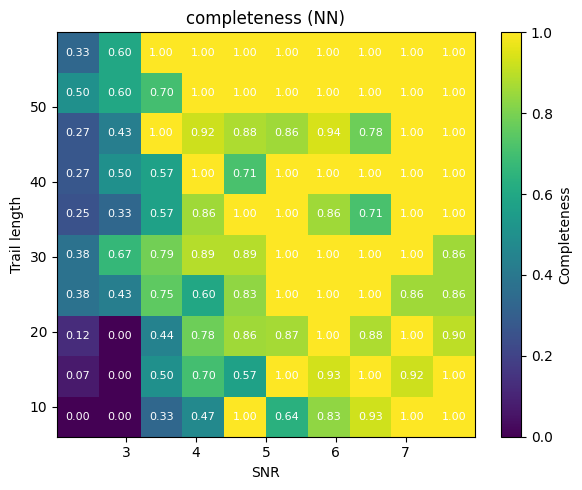

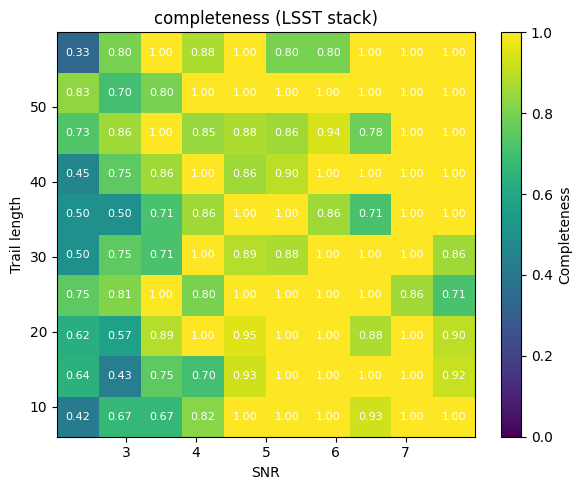

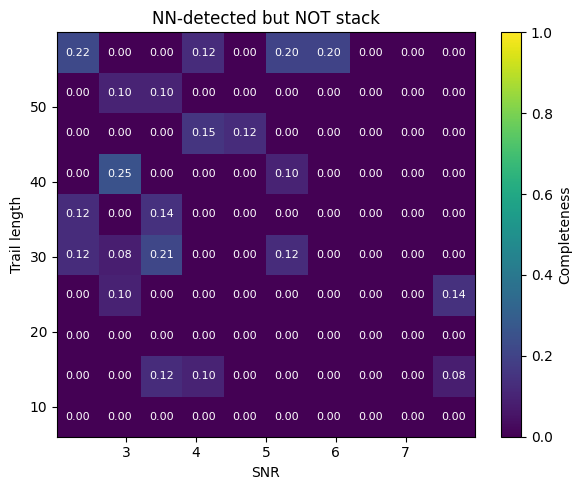

In [5]:
counts, t, pairs, cat = evaluate_set('test_3sigma')
show_confusion(counts, 'test_3sigma + NN — object-level (catalog trail-overlap)')
row = compare_methods('test_3sigma', counts, t)
for field, kw in [('PSF_mag', {}), ('trail_length', {}), ('SNR', dict(xlim=[0,10], density=True))]:
    evals.plot_detect_hist(t, field, bins=12, title='test_3sigma — All vs NN vs stack vs combined: '+field, **kw); plt.show()
evals.plot_completeness_2d(t, snr_bins=10, trail_bins=10, title='completeness (NN)'); plt.show()
evals.plot_completeness_2d(t, snr_bins=10, trail_bins=10, detected=t['stack_detection'].values, title='completeness (LSST stack)'); plt.show()
evals.plot_completeness_2d(t, snr_bins=10, trail_bins=10, detected=(~t['stack_detection'].values & t['nn_detected'].values.astype(bool)), title='NN-detected but NOT stack'); plt.show()

## Cross-σ summary — NN vs LSST stack vs combined (recall + FP)


[test_5sigma] NN vs LSST-stack vs combined (n=1000 truth trails, 50 panels):
  LSST stack : recall=0.475 (475)   FP=6405  (128.1/panel)
  v7+RF NN   : recall=0.725 (725)   FP=3575  (71.5/panel)
  combined   : recall=0.739 (739)
  NN recovers 264 stack-missed trails (pure 2nd-stage gain)



[test_4sigma] NN vs LSST-stack vs combined (n=1000 truth trails, 50 panels):
  LSST stack : recall=0.682 (682)   FP=15029  (300.6/panel)
  v7+RF NN   : recall=0.744 (744)   FP=2838  (56.8/panel)
  combined   : recall=0.786 (786)
  NN recovers 104 stack-missed trails (pure 2nd-stage gain)



[test_3sigma] NN vs LSST-stack vs combined (n=1000 truth trails, 50 panels):
  LSST stack : recall=0.879 (879)   FP=142072  (2841.4/panel)
  v7+RF NN   : recall=0.788 (788)   FP=1558  (31.2/panel)
  combined   : recall=0.909 (909)
  NN recovers 30 stack-missed trails (pure 2nd-stage gain)

    set  NN_recall  stack_recall  combined_recall  NN_FP  NN_FP_pp  stack_FP  stack_FP_pp
5sigma      0.725         0.475            0.739   3575      71.5      6405        128.1
4sigma      0.744         0.682            0.786   2838      56.8     15029        300.6
3sigma      0.788         0.879            0.909   1558      31.2    142072       2841.4


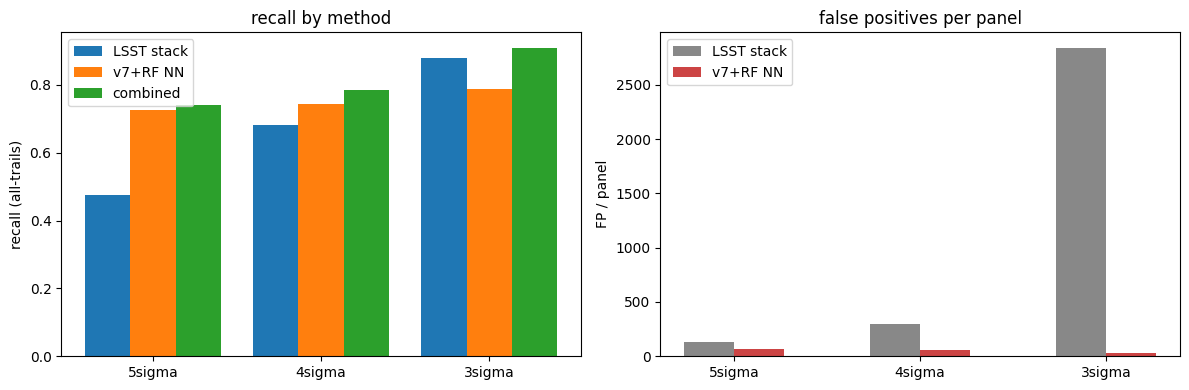

In [6]:
rows=[compare_methods(n, *evaluate_set(n)[:2]) for n in SETS]
summary=pd.DataFrame(rows); print('\n', summary.to_string(index=False))
x=np.arange(len(SETS)); w=0.27
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].bar(x-w, summary.stack_recall, w, label='LSST stack'); ax[0].bar(x, summary.NN_recall, w, label='v7+RF NN'); ax[0].bar(x+w, summary.combined_recall, w, label='combined')
ax[0].set_xticks(x); ax[0].set_xticklabels(summary.set); ax[0].set_ylabel('recall (all-trails)'); ax[0].legend(); ax[0].set_title('recall by method')
ax[1].bar(x-w/2, summary.stack_FP_pp, w, label='LSST stack', color='#888'); ax[1].bar(x+w/2, summary.NN_FP_pp, w, label='v7+RF NN', color='#c44')
ax[1].set_xticks(x); ax[1].set_xticklabels(summary.set); ax[1].set_ylabel('FP / panel'); ax[1].legend(); ax[1].set_title('false positives per panel')
plt.tight_layout(); plt.show()